# **Project Report: Telecom Customer Churn Analysis and Prediction**

This report documents the process of developing Machine Learning models to predict Customer Churn in the telecommunications industry dataset. The methodology includes data cleaning, exploratory analysis, preprocessing, training three algorithms (Logistic Regression, Decision Tree, K-Nearest Neighbors), performance evaluation, and model interpretability using SHAP and fairness audits. Dataset link: [Kaggle](https://www.kaggle.com/datasets/palashfendarkar/wa-fnusec-telcocustomerchurn)

## **CHAPTER 1: Data Understanding & Cleaning (Data Understanding & Cleaning)**
A fundamental stage in the data science project lifecycle is understanding the dataset structure and handling initial anomalies. This chapter documents the data acquisition process, checking variable types, and corrective actions against data inconsistencies to ensure the validity of subsequent analysis.

### **1.1 Pemuatan Pustaka dan Dataset**
Langkah pertama melibatkan impor pustaka komputasi esensial. Pustaka Pandas dan NumPy digunakan untuk manipulasi struktur data tabular, Matplotlib dan Seaborn untuk visualisasi data, serta Scikit-Learn untuk kebutuhan pemodelan prediktif dan evaluasi. Dataset Telco Customer Churn dimuat langsung dari repositori daring untuk memastikan aksesibilitas dan reproduksibilitas. Pemeriksaan awal dilakukan menggunakan fungsi info() untuk mengidentifikasi dimensi data, tipe variabel, dan penggunaan memori.

In [40]:
# Import Pustaka
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Pustaka Modeling & Evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from matplotlib.colors import ListedColormap

# Konfigurasi Visualization
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# Memuat Dataset
df = pd.read_csv('https://github.com/LaboNapitupulu/Academic-Data-Lake/raw/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Displaying sampel data dan informasi struktur
display(df.head())
print("\nInformasi Struktur Dataset:")
print(df.info())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Informasi Struktur Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBill

Berdasarkan tinjauan awal terhadap struktur dataset yang memuat 7.043 entri dan 21 kolom, ditemukan anomali struktural yang signifikan pada kolom `TotalCharges`. Meskipun kolom ini secara logis merepresentasikan nilai finansial numerik (seperti halnya `MonthlyCharges` yang teridentifikasi dengan benar sebagai `float64`), sistem membacanya sebagai tipe data `object` (string). Ketidaksesuaian ini mengindikasikan keberadaan karakter non-numerik—kemungkinan besar berupa spasi kosong atau *string* kosong—di dalam baris data, yang biasanya terjadi pada pelanggan baru dengan masa berlangganan (*tenure*) nol bulan. Kondisi ini mengharuskan adanya langkah pembersihan data spesifik berupa konversi tipe data ke numerik dan penanganan nilai yang hilang (*missing values*) sebelum fitur ini dapat diikutsertakan dalam kalkulasi matematis model. Selebihnya, dataset didominasi oleh fitur kategorikal tipe `object` (seperti `gender`, `Partner`, `PaymentMethod`) dan target prediksi `Churn`, yang seluruhnya memerlukan proses *encoding* agar dapat diproses oleh algoritma pembelajaran mesin.

### **1.2 Penanganan Anomali pada Fitur Numerik**
Berdasarkan tinjauan struktur data, ditemukan anomali pada kolom TotalCharges. Variabel ini secara semantik merepresentasikan nilai finansial (numerik), namun terdeteksi oleh sistem sebagai tipe data object (string). Hal ini umumnya disebabkan oleh adanya karakter non-numerik, spesifiknya spasi kosong (whitespace), yang muncul pada entri pelanggan dengan masa berlangganan (tenure) 0 bulan.

Tindakan perbaikan yang dilakukan meliputi:
1. Konversi Paksa ke Numerik: Changing tipe data menjadi numerik, di mana nilai yang tidak valid akan dikonversi menjadi NaN (Not a Number).
2. Identifikasi Value Hilang: Menghitung jumlah entri yang gagal dikonversi.
3. Imputasi Data: Filling nilai NaN dengan nilai 0, didasarkan pada logika bisnis bahwa pelanggan baru belum memiliki akumulasi tagihan.

In [41]:
# Konversi ke numerik, error (spasi) diubah menjadi NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Identifikasi jumlah data yang hilang
missing_charges = df['TotalCharges'].isnull().sum()
print(f"Jumlah nilai hilang (NaN) pada TotalCharges: {missing_charges}")

# Imputasi nilai hilang dengan 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("Konversi tipe data TotalCharges selesai.")

Jumlah nilai hilang (NaN) pada TotalCharges: 11
Konversi tipe data TotalCharges selesai.


Proses konversi tipe data pada kolom `TotalCharges` dari format *object* menjadi numerik telah berhasil dilakukan. Hasil konversi ini secara spesifik mengidentifikasi adanya **11 entri data** yang validitasnya kosong (terdeteksi sebagai *NaN*), yang sebelumnya tersembunyi dalam bentuk karakter spasi atau *string* kosong. Penemuan ini mengonfirmasi perlunya penanganan nilai hilang (*missing values*) pada tahap selanjutnya untuk memastikan integritas data sebelum digunakan dalam komputasi model.

### **1.3 Pemeriksaan Kualitas Data**
Setelah penanganan anomali spesifik, dilakukan pemeriksaan menyeluruh terhadap kualitas data. Pemeriksaan ini mencakup dua aspek vital:
1. Deteksi Missing Values: Memastikan tidak ada kolom lain yang mengandung nilai kosong yang dapat mendistorsi kinerja model.
2. Deteksi Duplikasi: Memastikan keunikan setiap baris data untuk mencegah bias yang disebabkan oleh data ganda (redundancy).

In [42]:
# Pemeriksaan nilai hilang per kolom
print("Jumlah Missing Values per Kolom:")
print(df.isnull().sum())

# Pemeriksaan duplikasi baris
jumlah_duplikat = df.duplicated().sum()
print(f"\nJumlah Baris Duplikat: {jumlah_duplikat}")

Jumlah Missing Values per Kolom:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Jumlah Baris Duplikat: 0


Pemeriksaan integritas data pasca-pembersihan mengonfirmasi bahwa dataset kini memiliki tingkat kelengkapan dan validitas yang optimal. Seluruh 21 atribut tercatat bebas dari nilai yang hilang (*missing values*), termasuk kolom `TotalCharges` yang sebelumnya bermasalah. Selain itu, verifikasi redundansi menunjukkan angka nol pada jumlah baris duplikat, yang menjamin bahwa setiap entri data merepresentasikan observasi pelanggan yang unik. Kondisi data yang bersih dan lengkap ini memenuhi syarat teknis untuk dilanjutkan ke tahapan eksplorasi dan pemodelan tanpa risiko bias akibat kekosongan atau pengulangan data.

## **CHAPTER 2: Exploratory Data Analysis Data (Exploratory Data Analysis)**
Setelah data dinyatakan bersih secara struktural, tahap selanjutnya adalah Exploratory Data Analysis Data (EDA). Tahap ini bertujuan untuk mengidentifikasi pola distribusi variabel target, mendeteksi ketidakseimbangan kelas, serta menganalisis korelasi antara atribut fitur (seperti layanan dan biaya) dengan keputusan pelanggan untuk berhenti berlangganan (Churn). Wawasan yang diperoleh dari tahap ini akan menjadi landasan dalam pemilihan strategi pemrosesan data dan pemodelan.

### **2.1 Analisis Keseimbangan Target**
Langkah awal dalam analisis eksploratif adalah memeriksa proporsi kelas pada variabel target Churn. Pemahaman mengenai keseimbangan kelas sangat krusial karena ketidakseimbangan data (class imbalance) dapat menyebabkan model menjadi bias, di mana model cenderung memprediksi kelas mayoritas dengan akurasi tinggi namun gagal mendeteksi kelas minoritas.

Kode berikut memvisualisasikan distribusi jumlah pelanggan yang bertahan (No) dibandingkan dengan yang berhenti (Yes), serta menghitung persentase proporsinya.

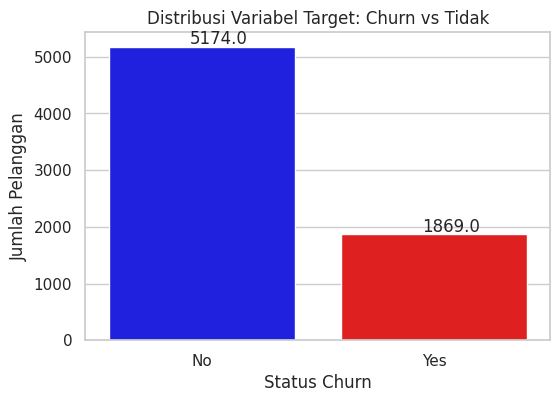

Proporsi Kelas Target:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [43]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, palette=['#0000FF', '#FF0000'])
plt.title('Distribution Variabel Target: Churn vs Tidak')
plt.xlabel('Status Churn')
plt.ylabel('Jumlah Pelanggan')

# Menambahkan anotasi angka
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.35, p.get_height() + 50))
plt.show()

# Displaying proporsi persentase
print("Proporsi Kelas Target:")
print(df['Churn'].value_counts(normalize=True) * 100)

Analisis distribusi kelas pada variabel target `Churn` mengungkapkan adanya ketidakseimbangan kelas (*class imbalance*) yang cukup signifikan. Mayoritas data, yakni sebesar **73,46%**, merupakan pelanggan yang tetap berlangganan (kategori "No"), sedangkan hanya **26,54%** pelanggan yang memutuskan untuk berhenti (kategori "Yes"). Ketimpangan proporsi ini—dengan rasio hampir 3:1—mengindikasikan bahwa model prediksi akan memiliki kecenderungan bias terhadap kelas mayoritas jika hanya mengandalkan metrik akurasi semata. Oleh karena itu, strategi evaluasi harus memprioritaskan metrik yang lebih sensitif terhadap ketidakseimbangan, seperti *AUC-ROC* atau *F1-Score*, guna memastikan kemampuan model dalam mendeteksi kelas minoritas (*Churn*) tetap optimal.

### **2.2 Analisis Hubungan Fitur Utama**
Analisis ini bertujuan untuk menginvestigasi pengaruh atribut utama terhadap probabilitas Churn. Tiga faktor yang dianalisis meliputi:
1. Jenis Kontrak (Contract): Untuk melihat korelasi antara durasi komitmen pelanggan dengan tingkat retensi.
2. Layanan Internet (InternetService): Untuk mengevaluasi apakah jenis infrastruktur layanan mempengaruhi kepuasan pelanggan.
3. Tagihan Bulanan (MonthlyCharges): Untuk menguji hipotesis bahwa biaya yang lebih tinggi berkorelasi dengan kecenderungan pelanggan untuk berhenti.

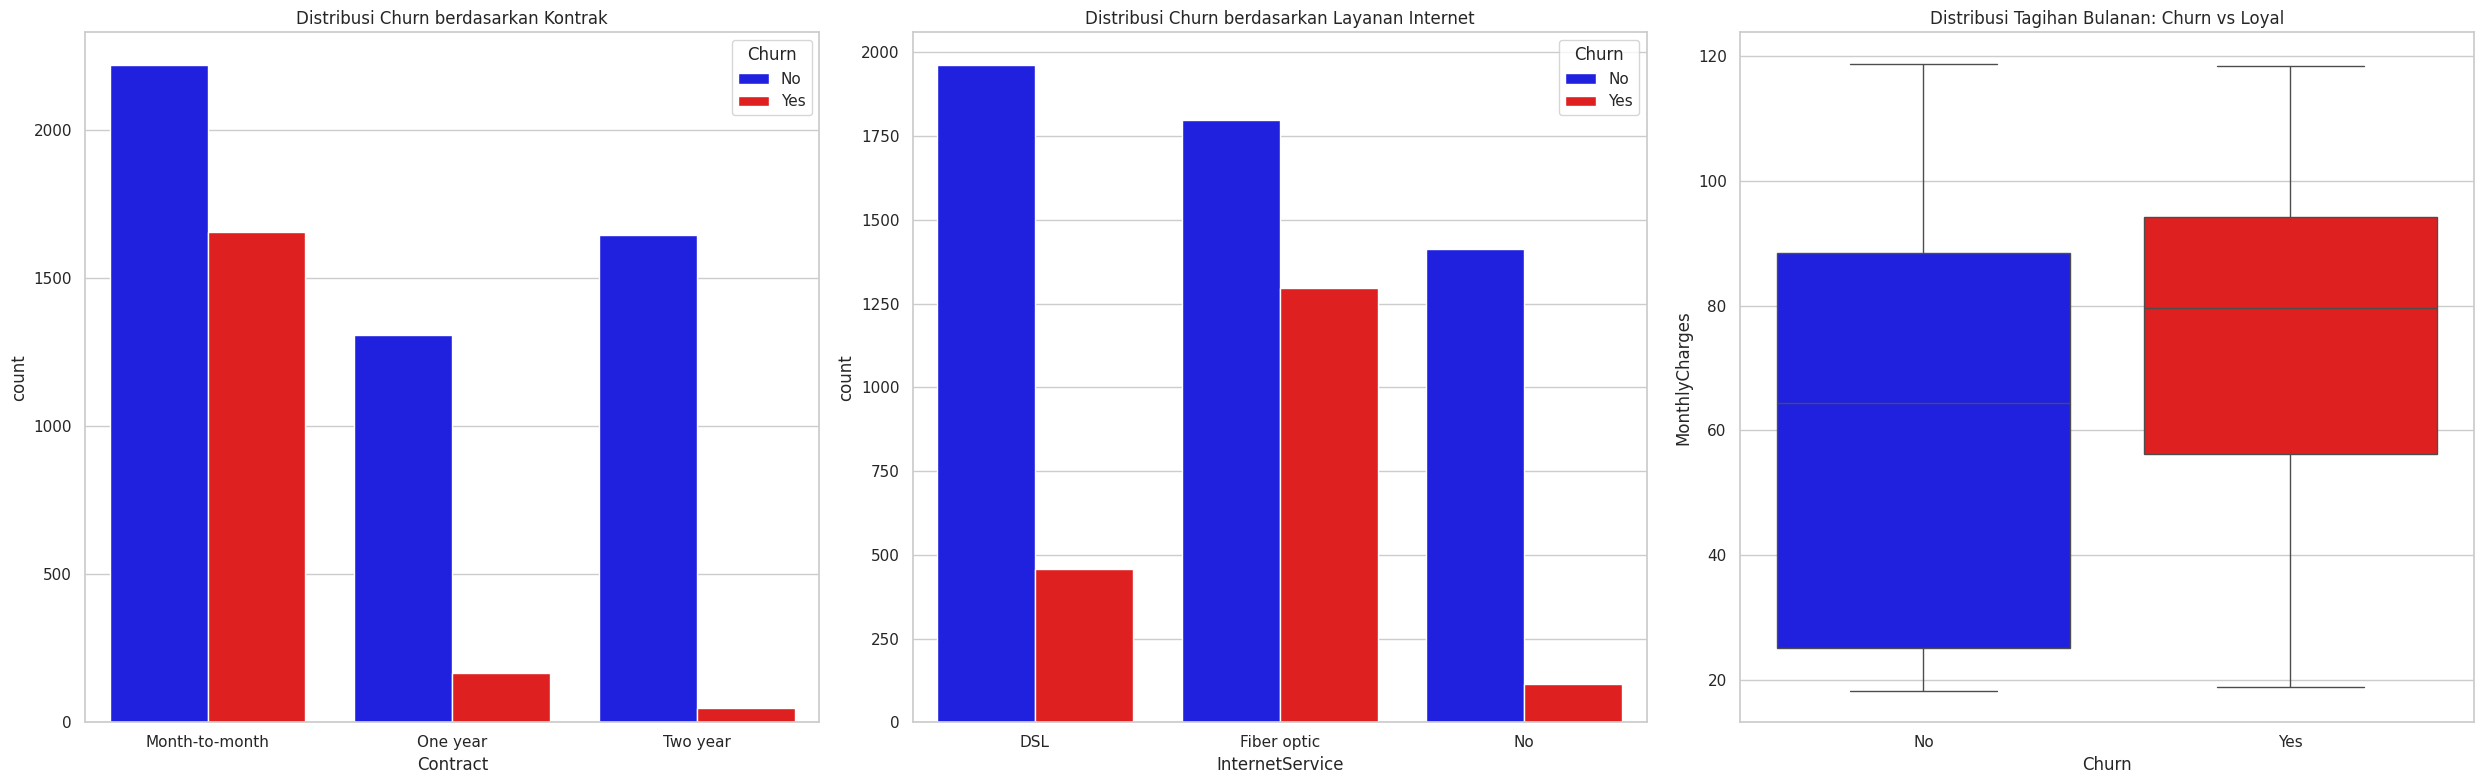

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(25, 8))

# Visualization 1: Pengaruh Jenis Kontrak
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0], palette=['#0000FF', '#FF0000'])
axes[0].set_title('Distribution Churn berdasarkan Kontrak')

# Visualization 2: Pengaruh Layanan Internet
sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[1], palette=['#0000FF', '#FF0000'])
axes[1].set_title('Distribution Churn berdasarkan Layanan Internet')

# Visualization 3: Pengaruh Tagihan Bulanan (Boxplot)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[2], palette=['#0000FF', '#FF0000'])
axes[2].set_title('Distribution Tagihan Bulanan: Churn vs Loyal')

plt.tight_layout()
plt.show()

Visualization data memperlihatkan korelasi yang signifikan antara atribut layanan dengan keputusan pelanggan untuk berhenti berlangganan (*Churn*). Pada aspek **Jenis Kontrak**, terdapat pola yang sangat mencolok di mana pelanggan dengan kontrak bulanan (*Month-to-month*) mendominasi tingkat *Churn* tertinggi dibandingkan jenis kontrak lainnya. Sebaliknya, pelanggan dengan kontrak jangka panjang (satu atau dua tahun) menunjukkan tingkat loyalitas yang jauh lebih tinggi dengan angka *Churn* yang minimal. Hal ini mengindikasikan bahwa fleksibilitas kontrak jangka pendek justru berkorelasi kuat dengan volatilitas pelanggan.


Analisis terhadap **Layanan Internet** mengungkapkan bahwa pengguna layanan *Fiber Optic* memiliki kecenderungan untuk *Churn* yang lebih tinggi dibandingkan pengguna *DSL* atau pelanggan tanpa layanan internet. Meskipun *Fiber Optic* umumnya menawarkan kecepatan lebih tinggi, tingginya tingkat *Churn* di segmen ini dapat mengindikasikan adanya isu sensitivitas harga atau ketidakpuasan terhadap kualitas layanan yang spesifik pada infrastruktur tersebut.



Selaras dengan temuan di atas, distribusi **Tagihan Bulanan** (*Monthly Charges*) memperlihatkan perbedaan karakteristik yang jelas antara kelompok pelanggan yang *Churn* dan yang setia. Pelanggan yang memutuskan untuk berhenti cenderung memiliki rata-rata tagihan bulanan yang lebih tinggi, sebagaimana ditunjukkan oleh posisi median *boxplot* yang lebih terangkat pada kelompok *Churn*. Temuan ini memperkuat hipotesis bahwa beban biaya bulanan merupakan faktor pendorong utama dalam keputusan pelanggan untuk beralih layanan.


## **CHAPTER 3: Preprocessing Data (Data Preprocessing)**
Kualitas model pembelajaran mesin sangat bergantung pada kualitas representasi data yang digunakan (Garbage In, Garbage Out). Tahap pra-pemrosesan ini bertujuan untuk mengubah variabel kategorikal menjadi format numerik, menyeleksi fitur yang relevan, mempartisi dataset untuk validasi, serta menyamakan skala distribusi data numerik agar kompatibel dengan algoritma berbasis jarak dan gradien.

### **3.1 Seleksi Fitur dan Pengkodean Target**
Langkah awal melibatkan eliminasi atribut yang tidak memiliki nilai prediktif. Atribut customerID dihapus karena hanya berfungsi sebagai pengenal unik administratif dan tidak merepresentasikan pola perilaku pelanggan. Selanjutnya, variabel target Churn yang memiliki format kategorikal nominal (Yes/No) ditransformasi menjadi format biner numerik (1/0). Transformasi ini merupakan prasyarat wajib agar variabel target dapat diproses oleh fungsi objektif algoritma klasifikasi.

In [45]:
# Penghapusan kolom ID
df_clean = df.drop('customerID', axis=1)

# Pengkodean biner variabel target
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

print("Sampel data setelah seleksi fitur:")
display(df_clean.head())

Sampel data setelah seleksi fitur:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Pada tahap awal pra-pemrosesan ini, struktur dataset telah disederhanakan melalui eliminasi atribut `customerID`, mengingat atribut tersebut hanya berfungsi sebagai penanda identitas unik tanpa kontribusi terhadap pola prediktif perilaku pelanggan. Bersamaan dengan itu, variabel target `Churn` telah berhasil ditransformasi dari format kategorikal nominal (*Yes/No*) menjadi format numerik biner. Value 1 kini merepresentasikan kejadian *Churn* (kelas positif) dan nilai 0 merepresentasikan pelanggan setia (kelas negatif). Langkah ini merupakan prasyarat fundamental dalam persiapan data, memastikan variabel target kompatibel dengan fungsi kerugian (*loss function*) pada algoritma pembelajaran mesin, sementara fitur kategorikal lainnya masih dipertahankan dalam format aslinya untuk diproses pada tahap selanjutnya.

### **3.2 Pengkodean Fitur Kategorikal (One-Hot Encoding)**
Sebagian besar fitur independen dalam dataset (seperti InternetService, PaymentMethod, Contract) bersifat kategorikal nominal. Algoritma pembelajaran mesin memerlukan input numerik. Oleh karena itu, teknik One-Hot Encoding diterapkan untuk mengubah setiap kategori unik menjadi kolom biner terpisah. Parameter drop_first=True digunakan untuk menghapus satu kolom dari setiap kategori guna mencegah Dummy Variable Trap (multikolinearitas sempurna antar variabel independen).

In [46]:
# Penerapan One-Hot Encoding
df_processed = pd.get_dummies(df_clean, drop_first=True)

print(f"Dimensi kolom sebelum encoding: {df_clean.shape[1]}")
print(f"Dimensi kolom setelah encoding: {df_processed.shape[1]}")
display(df_processed.head())

Dimensi kolom sebelum encoding: 20
Dimensi kolom setelah encoding: 31


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


Transformasi fitur kategorikal menggunakan teknik *One-Hot Encoding* telah mengubah struktur dimensi dataset secara signifikan, meningkatkan jumlah atribut dari 20 kolom menjadi 31 kolom. Ekspansi dimensi ini merupakan konsekuensi logis dari proses dekomposisi variabel kategorikal nominal (seperti *PaymentMethod* dan *Contract*) menjadi serangkaian variabel *dummy* biner yang saling independen. Sebagaimana terlihat pada sampel data, seluruh atribut kualitatif kini telah terkonversi menjadi representasi numerik (format Boolean/biner), di mana nilai `True` atau `1` menandakan keberadaan kategori tersebut pada pelanggan. Format matriks numerik penuh ini kini telah memenuhi syarat kompatibilitas matematis untuk diproses oleh algoritma pembelajaran mesin seperti *Logistic Regression* atau *KNN*.

### **3.3 Pemisahan Data Latih dan Uji**
Untuk mengukur kemampuan generalisasi model pada data yang belum pernah dilihat sebelumnya (unseen data), dataset dibagi menjadi dua subset: Data Latih (Training Set) dan Data Uji (Test Set). Mengingat adanya ketidakseimbangan kelas yang teridentifikasi pada Bab 2 (73:27), metode Stratified Sampling diterapkan. Metode ini menjamin bahwa proporsi kelas Churn pada data latih dan data uji tetap sama dengan proporsi populasi asli.

In [47]:
# Pemisahan variabel independen (X) dan dependen (y)
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

# Pembagian dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah Sampel Data Latih : {X_train.shape[0]}")
print(f"Jumlah Sampel Data Uji   : {X_test.shape[0]}")

Jumlah Sampel Data Latih : 5634
Jumlah Sampel Data Uji   : 1409


Untuk menjamin validitas evaluasi model dan mencegah kebocoran informasi (*data leakage*), dataset dipartisi menjadi dua subset independen dengan rasio 80:20. Proses ini menghasilkan **5.634 sampel data latih** (*training set*) yang dialokasikan untuk proses pembelajaran pola, serta **1.409 sampel data uji** (*test set*) yang disisihkan secara eksklusif untuk pengujian performa akhir. Penerapan teknik *stratified sampling* (parameter `stratify=y`) dalam pemisahan ini memainkan peran krusial guna memastikan bahwa proporsi distribusi kelas target (*Churn* vs *Non-Churn*) tetap konsisten dan representatif pada kedua subset, sehingga hasil evaluasi tidak bias oleh ketidakseimbangan kelas.

### **3.4 Skala Fitur (Feature Scaling)**
Dataset mengandung fitur numerik dengan rentang skala yang sangat berbeda, misalnya tenure (0-72 bulan) dan TotalCharges (0-8000+ USD). Perbedaan skala ini dapat menyebabkan bias pada algoritma yang mengandalkan perhitungan jarak Euclidean (seperti KNN) atau algoritma yang menggunakan optimasi gradien (seperti Logistic Regression).

Teknik Standard Scaler (Z-Score Normalization) diterapkan untuk mengubah distribusi setiap fitur numerik sehingga memiliki rata-rata ($\mu$) 0 dan standar deviasi ($\sigma$) 1. Penting dicatat bahwa objek scaler hanya "dipelajari" (fit) dari data latih, kemudian diaplikasikan (transform) ke data latih dan uji, guna mencegah kebocoran data (data leakage).

In [48]:
scaler = StandardScaler()

# Fitting hanya pada data latih untuk mencegah kebocoran data (data leakage)
scaler.fit(X_train)

# Transformasi data latih dan uji
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Konversi kembali ke DataFrame untuk kemudahan interpretasi
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

display(X_train_final.head())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.441773,0.102371,-0.521976,-0.262257,0.994336,-0.969234,-0.651557,-3.013090,3.013090,-0.858338,...,-0.524081,1.252163,-0.524081,1.247967,-0.512782,-0.563822,-1.202653,-0.523806,1.406903,-0.543846
1,-0.441773,-0.711743,0.337478,-0.503635,0.994336,1.031742,1.534786,0.331885,-0.331885,-0.858338,...,-0.524081,-0.798618,-0.524081,-0.801303,-0.512782,-0.563822,-1.202653,-0.523806,-0.710781,1.838757
2,-0.441773,-0.793155,-0.809013,-0.749883,0.994336,1.031742,1.534786,-3.013090,3.013090,-0.858338,...,-0.524081,-0.798618,-0.524081,-0.801303,-0.512782,1.773611,-1.202653,-0.523806,-0.710781,1.838757
3,-0.441773,-0.263980,0.284384,-0.172722,-1.005696,1.031742,-0.651557,0.331885,-0.331885,-0.858338,...,-0.524081,1.252163,-0.524081,1.247967,-0.512782,1.773611,0.831495,1.909105,-0.710781,-0.543846
4,-0.441773,-1.281624,-0.676279,-0.989374,0.994336,1.031742,1.534786,0.331885,-0.331885,-0.858338,...,-0.524081,-0.798618,-0.524081,-0.801303,-0.512782,-0.563822,-1.202653,-0.523806,1.406903,-0.543846


Tahap standarisasi fitur dilakukan menggunakan metode *StandardScaler* untuk menyeragamkan distribusi nilai pada seluruh atribut numerik, sehingga memiliki rata-rata nol dan deviasi standar satu. Proses kalkulasi parameter statistik (*fitting*) diterapkan secara eksklusif pada data latih (*X_train*) guna mencegah kebocoran data (*data leakage*) yang dapat membiaskan evaluasi model, sebelum kemudian diaplikasikan untuk mentransformasi data latih dan data uji. Sebagaimana terlihat pada sampel data hasil transformasi, nilai-nilai asli pada fitur seperti `tenure` dan `MonthlyCharges` kini telah dikonversi menjadi skor-Z (contoh: -0.441773 atau 0.102371). Normalisasi ini bertujuan menghilangkan disparitas skala antar variabel yang memiliki satuan berbeda (misalnya bulan vs mata uang), yang merupakan prasyarat krusial untuk mengoptimalkan konvergensi algoritma berbasis gradien dan akurasi algoritma berbasis jarak seperti *K-Nearest Neighbors*.

## **CHAPTER 4: Modeling dan Evaluation (Modeling & Evaluation)**
Tahap ini berfokus pada pembangunan model prediktif menggunakan tiga algoritma pembelajaran mesin dengan karakteristik berbeda: Logistic Regression (linear), Decision Tree (berbasis aturan), dan K-Nearest Neighbors (berbasis jarak). Pendekatan sistematis diterapkan mulai dari pencarian parameter optimal, pelatihan model, hingga evaluasi kinerja menggunakan metrik statistik dan visualisasi diagnostik.

### **4.1 Optimasi Hiperparameter K-Nearest Neighbors (KNN)**
Penggunaan nilai tetangga ($K$) yang statis pada algoritma KNN berpotensi menghasilkan model yang suboptimal. Value $K$ yang terlalu kecil dapat menyebabkan overfitting (terlalu sensitif terhadap noise), sedangkan nilai yang terlalu besar dapat menyebabkan underfitting (kehilangan pola lokal). Oleh karena itu, metode Grid Search Cross-Validation diterapkan untuk menguji serangkaian nilai $K$ ganjil (1 hingga 21) guna menemukan konfigurasi yang menghasilkan akurasi validasi tertinggi secara empiris.

In [49]:
from sklearn.model_selection import GridSearchCV

# 1. Definisi Ruang Pencarian Parameter
# Menguji nilai K ganjil dari 1 hingga 21 untuk menghindari hasil seri (voting ties)
param_grid = {'n_neighbors': np.arange(1, 22, 2)}

# 2. Inisialisasi Grid Search
# Menggunakan 5-Fold Cross Validation untuk validasi internal yang robust
knn_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# 3. Eksekusi Pencarian pada Data Latih
knn_search.fit(X_train_final, y_train)

# 4. Ekstraksi Model Terbaik
best_k = knn_search.best_params_['n_neighbors']
best_knn_model = knn_search.best_estimator_

print(f"--> Value K Optimal yang ditemukan : {best_k}")
print(f"--> Skor Accuracy Validasi Terbaik  : {knn_search.best_score_:.2%}")

--> Nilai K Optimal yang ditemukan : 21
--> Skor Akurasi Validasi Terbaik  : 78.98%


Proses Grid Search mengidentifikasi bahwa jumlah tetangga optimal adalah $K=21$, yang merupakan batas atas dari ruang pencarian yang ditentukan. Pemilihan nilai $K$ yang tinggi ini mengindikasikan bahwa model membutuhkan area pemungutan suara (voting area) yang lebih luas untuk meredam noise pada data dan menghasilkan batas keputusan yang lebih stabil (mengurangi varians). Dengan konfigurasi ini, model mencapai akurasi validasi sebesar 78.98%, yang menunjukkan peningkatan signifikan dibandingkan baseline accuracy (73.4%).

### **4.2 Pelatihan Komparatif dan Evaluation Metrik Numerik**
Setelah mendapatkan parameter optimal untuk KNN, tahap selanjutnya adalah melatih ketiga algoritma utama pada data latih dan mengevaluasinya pada data uji yang terpisah (hold-out set).

Metrik evaluasi yang digunakan meliputi:
1. Accuracy Uji (Test Accuracy): Persentase prediksi yang benar secara keseluruhan.
2. Validasi Silang (CV Mean Accuracy): Rata-rata akurasi dari 5 lipatan data latih untuk mengukur stabilitas model.
3. AUC-ROC (Area Under Curve): Kemampuan model membedakan antara kelas positif (Churn) dan negatif (Setia), metrik ini lebih reliabel untuk data tidak seimbang dibandingkan akurasi.

In [50]:
# Inisialisasi Model Komparatif
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42), # Kedalaman dibatasi untuk generalisasi
    "KNN (Tuned)": best_knn_model  # Menggunakan model KNN hasil optimasi GridSearch
}

results = {}

print("Laporan Evaluation Kinerja Model:")
for name, model in models.items():
    # 1. Pelatihan Model (Fitting)
    model.fit(X_train_final, y_train)

    # 2. Prediction pada Data Uji
    y_pred = model.predict(X_test_final)
    # Mengambil probabilitas kelas positif (1) untuk perhitungan AUC
    y_prob = model.predict_proba(X_test_final)[:, 1]

    # 3. Validasi Silang (Stratified 5-Fold)
    # Menghitung konsistensi performa pada data latih
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train_final, y_train, cv=skf, scoring='accuracy')

    # 4. Penyimpanan Metrik Evaluation
    results[name] = {
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'CV Mean Accuracy': cv_scores.mean(),
        'AUC Score': roc_auc_score(y_test, y_prob)
    }

    # 5. Pelaporan Hasil
    print(f"\nModel: {name}")
    print(f"Accuracy Data Uji  : {results[name]['Test Accuracy']:.2%}")
    print(f"Rata-rata CV      : {results[name]['CV Mean Accuracy']:.2%}")
    print(f"Skor AUC          : {results[name]['AUC Score']:.4f}")

Laporan Evaluasi Kinerja Model:

Model: Logistic Regression
Akurasi Data Uji  : 80.70%
Rata-rata CV      : 80.25%
Skor AUC          : 0.8418

Model: Decision Tree
Akurasi Data Uji  : 79.42%
Rata-rata CV      : 78.97%
Skor AUC          : 0.8267

Model: KNN (Tuned)
Akurasi Data Uji  : 77.08%
Rata-rata CV      : 78.83%
Skor AUC          : 0.8105


Berdasarkan hasil evaluasi komparatif, algoritma Logistic Regression menunjukkan kinerja paling superior di antara ketiga model yang diuji. Model ini mencatatkan Accuracy Data Uji tertinggi sebesar 80.70% serta skor AUC sebesar 0.8418, yang mengindikasikan kemampuan diskriminatif terbaik dalam memisahkan kelas Churn dan Non-Churn.

Konsistensi model juga terkonfirmasi melalui selisih yang sangat tipis antara Accuracy Uji dan Rata-rata Validasi Silang (CV) pada semua algoritma (selisih < 2%), yang menandakan bahwa model memiliki kemampuan generalisasi yang baik dan tidak mengalami overfitting. Decision Tree menempati posisi kedua dengan kinerja yang kompetitif (Accuracy 79.42%), sementara KNN (Tuned) mencatatkan performa terendah dengan akurasi 77.08% dan AUC 0.8105. Temuan ini mengindikasikan bahwa karakteristik dataset lebih cocok didekati dengan model linear dibandingkan pendekatan berbasis jarak pada dimensi tinggi.

## **CHAPTER 5: Interpretabilitas Model (Model Interpretability)**
Selain metrik akurasi, aspek krusial dalam penerapan pembelajaran mesin di industri adalah kemampuan untuk menjelaskan alasan di balik prediksi (explainability). Bab ini menganalisis "Kepentingan Fitur" (Feature Importance) untuk mengidentifikasi atribut pelanggan yang paling berkontribusi terhadap risiko Churn. Dua pendekatan digunakan: analisis koefisien linear pada Logistic Regression dan analisis Information Gain pada Decision Tree.

### **5.1 Analisis Faktor Determinan (Global Feature Importance)**
Analisis ini membandingkan bagaimana dua algoritma berbeda memandang data:
1. Logistic Regression: Melihat hubungan linear. Value koefisien positif (+) menandakan faktor pendorong Churn, sedangkan negatif (-) menandakan faktor pencegah (retensi).
2. Decision Tree: Melihat hierarki kepentingan. Fitur dengan nilai importance tertinggi adalah fitur yang paling sering dan paling efektif digunakan untuk memisahkan data di setiap percabangan pohon.

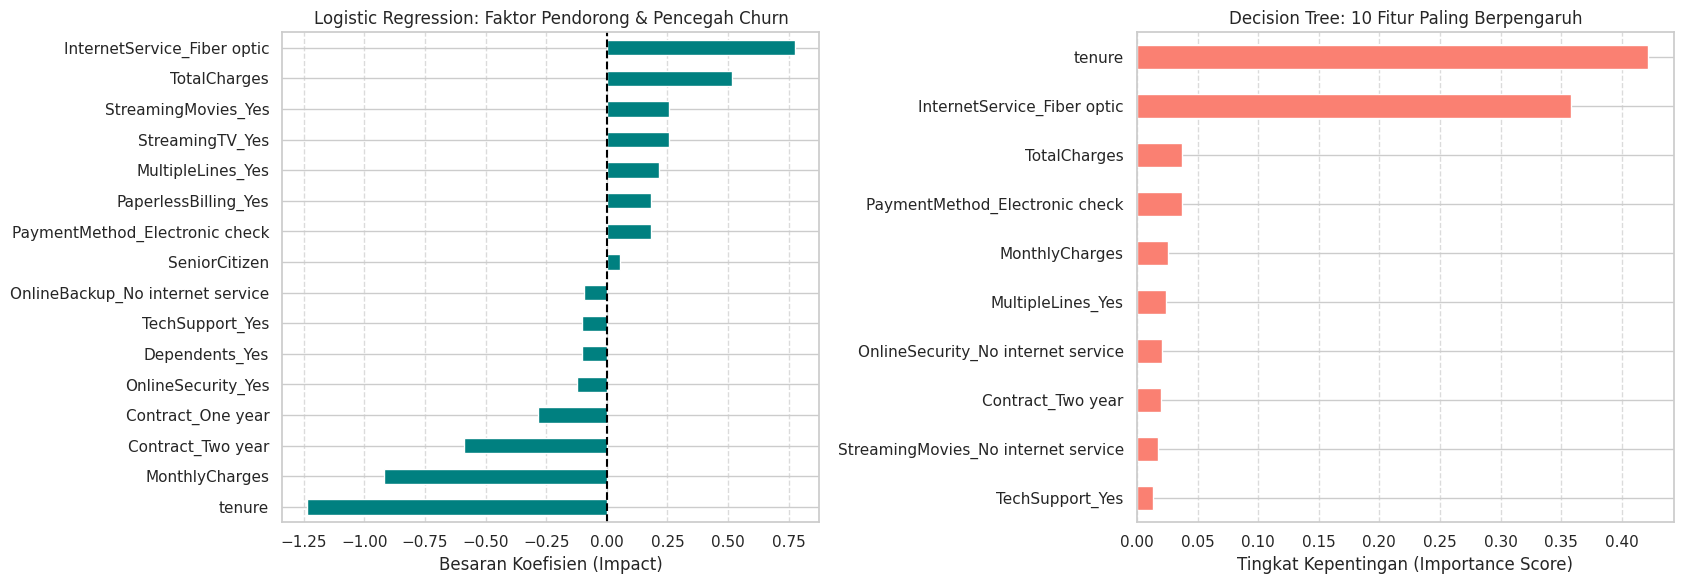

In [51]:
# Konfigurasi Grid Visualization
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# A. Visualization Koefisien Logistic Regression
# Ekstraksi koefisien
log_coef = pd.Series(models['Logistic Regression'].coef_[0], index=X.columns)

# Mengambil 8 fitur pendorong Churn (Positif) dan 8 fitur penahan Churn (Negatif) terkuat
top_log_coef = pd.concat([log_coef.sort_values().head(8), log_coef.sort_values().tail(8)])

# Plotting Bar Chart Horizontal
top_log_coef.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Logistic Regression: Faktor Pendorong & Pencegah Churn')
axes[0].set_xlabel('Besaran Koefisien (Impact)')
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# B. Visualization Decision Tree Feature Importance
# Ekstraksi nilai importance
tree_imp = pd.Series(models['Decision Tree'].feature_importances_, index=X.columns)

# Mengambil 10 fitur dengan Information Gain tertinggi
tree_imp.sort_values(ascending=False).head(10).plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Decision Tree: 10 Fitur Paling Berpengaruh')
axes[1].set_xlabel('Tingkat Kepentingan (Importance Score)')
axes[1].invert_yaxis() # Mengurutkan dari yang terbesar di atas
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Analisis determinan *churn* mengungkapkan konsistensi pola antara model linear dan non-linear mengenai faktor risiko utama. Berdasarkan koefisien **Logistic Regression**, ditemukan dikotomi yang jelas: variabel seperti **Tenure** dan **TotalCharges** memiliki koefisien negatif yang signifikan, menandakan fungsinya sebagai faktor protektif (retensi), sedangkan variabel terkait biaya dan layanan premium seperti **MonthlyCharges** dan **Fiber Optic** memiliki koefisien positif, yang berkorelasi kuat dengan peningkatan probabilitas *churn*. Temuan ini divalidasi oleh model **Decision Tree**, yang menempatkan **Tenure**, **InternetService_Fiber optic**, dan **TotalCharges** sebagai tiga fitur teratas dalam hierarki *Information Gain*. Konvergensi hasil dari kedua model ini menegaskan bahwa durasi berlangganan (*Tenure*) dan akumulasi nilai moneter (*TotalCharges*) adalah indikator loyalitas terkuat, sementara penggunaan infrastruktur *Fiber Optic* menjadi indikator risiko utama yang memerlukan strategi mitigasi khusus.

### **5.2 Visualization Logika Keputusan (Decision Tree Rules)**
Salah satu keunggulan utama Decision Tree adalah sifatnya sebagai model White-box, di mana logika pengambilan keputusan dapat divisualisasikan secara eksplisit layaknya diagram alir (flowchart). Visualization berikut menampilkan struktur dari pohon keputusan yang telah dilatih, menunjukkan aturan "JIKA-MAKA" yang digunakan model untuk mengklasifikasikan pelanggan.

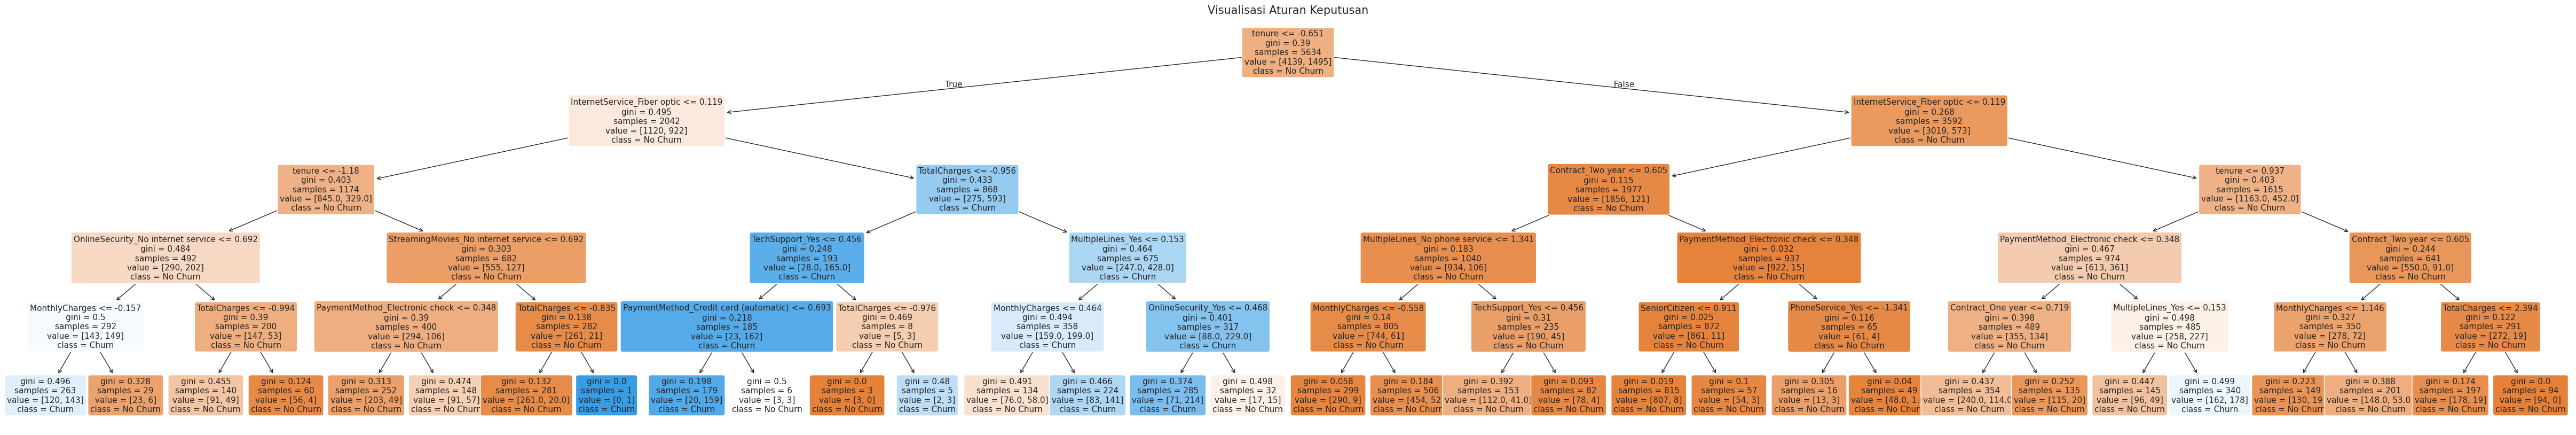

In [52]:
# Visualization Struktur Pohon Keputusan
plt.figure(figsize=(62, 10))

# Displaying pohon dengan kedalaman terbatas (max_depth=3) agar tetap terbaca
plot_tree(models['Decision Tree'],
          feature_names=X.columns,
          class_names=['No Churn', 'Churn'], # 0: No, 1: Yes
          filled=True,
          rounded=True,
          max_depth=5,
          fontsize=11)

plt.title("Visualization Aturan Keputusan", fontsize=15)
plt.show()

Analisis struktur pohon keputusan secara tekstual menyingkap hierarki logika model yang sangat tajam, di mana **`tenure` (masa berlangganan)** berfungsi sebagai gerbang utama seleksi risiko dengan nilai ambang batas terstandarisasi -0.65. Pemisahan ini secara tegas mengelompokkan data menjadi populasi "Pelanggan Baru" (di bawah rata-rata) dan "Pelanggan Lama". Temuan paling krusial terletak pada Level 1, di mana variabel **`InternetService_Fiber optic`** muncul secara konsisten sebagai penentu sekunder di kedua cabang, menandakan bahwa jenis infrastruktur internet adalah faktor determinan universal tanpa memandang durasi langganan. Secara spesifik, kombinasi antara durasi berlangganan yang singkat (cabang atas) dan penggunaan layanan Fiber Optic (cabang `> 0.12`) teridentifikasi sebagai jalur dengan risiko volatilitas tertinggi, di mana model selanjutnya menggunakan variabel moneter seperti `TotalCharges` dan `MonthlyCharges` untuk memfinalisasi prediksi *churn* (Class 1), berbeda dengan cabang pelanggan lama yang mayoritas diklasifikasikan setia (Class 0) kecuali pada kondisi kontrak tertentu.

### **5.3 Visualization Batas Keputusan KNN (KNN Decision Boundary)**
Mengingat algoritma KNN bekerja berdasarkan jarak, visualisasi ini memetakan "wilayah kekuasaan" kelas Churn vs Loyal dalam ruang 2 dimensi menggunakan dua fitur paling dominan: Tenure (Sumbu X) dan MonthlyCharges (Sumbu Y).

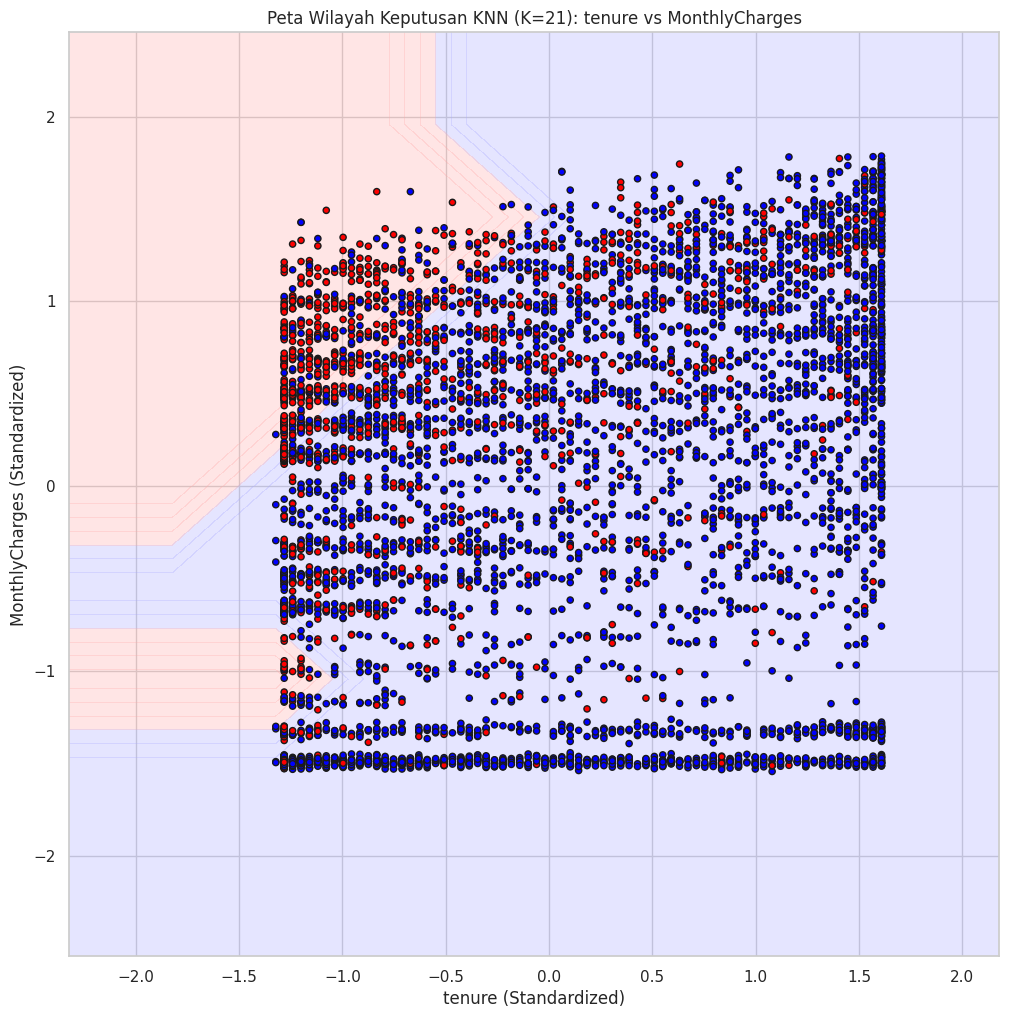

In [53]:
from matplotlib.colors import ListedColormap

# 1. Seleksi 2 Fitur Utama untuk Visualization 2D
col_x = 'tenure'
col_y = 'MonthlyCharges'

# Mengambil data latih hanya untuk 2 kolom tersebut
X_vis = X_train_final[[col_x, col_y]].values
y_vis = y_train.values

# 2. Training ulang model KNN khusus untuk visualisasi 2D ini
# (Menggunakan parameter terbaik hasil tuning sebelumnya)
clf_vis = KNeighborsClassifier(n_neighbors=best_k).fit(X_vis, y_vis)

# 3. Creating Meshgrid (Jaring titik latar belakang)
h = .5  # Kerapatan jaring
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 4. Prediction wilayah kelas untuk setiap titik di latar belakang
Z = clf_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Plotting Contour
plt.figure(figsize=(12, 12))
# Warna latar: Merah Muda (Churn), Biru Muda (Setia)
cmap_light = ListedColormap(['#AAAAFF', '#FFAAAA'])
# Warna titik: Biru Tua (Setia), Merah Tua (Churn)
cmap_bold = ListedColormap(['#0000FF', '#FF0000'])

plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.3)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap=cmap_bold, edgecolor='k', s=20)

plt.title(f"Peta Wilayah Keputusan KNN (K={best_k}): {col_x} vs {col_y}")
plt.xlabel(f"{col_x} (Standardized)")
plt.ylabel(f"{col_y} (Standardized)")
plt.show()

Peta visualisasi KNN memperlihatkan pola non-linear yang kompleks. Wilayah merah (Churn) terkonsentrasi di area kiri-atas, yang merepresentasikan pelanggan dengan Tenure rendah (kiri) namun memiliki Tagihan Bulanan tinggi (atas). Sebaliknya, wilayah biru (Loyal) mendominasi area kanan (Tenure tinggi) atau area bawah (Tagihan rendah). Batas yang tidak beraturan antar kedua wilayah menunjukkan bahwa KNN berusaha menangkap nuansa lokal data, berbeda dengan garis lurus kaku yang dihasilkan model linear.

## **CHAPTER 6: Analisis Diagnostik dan Lanjutan (Diagnostic & Advanced Analysis)**
Bab ini menyajikan evaluasi komprehensif terhadap seluruh model kandidat. Analisis dilakukan tidak hanya berdasarkan metrik tunggal, melainkan melalui pembedahan distribusi kesalahan (Confusion Matrix), analisis kemampuan diskriminatif (ROC Curves), diagnosis stabilitas (Learning Curves), serta investigasi data.

### **6.1 Dekomposisi Kesalahan Prediction (Confusion Matrix Comparison)**
Analisis ini membandingkan profil risiko ketiga model. Fokus utama adalah meminimalkan False Negative (FN), yaitu kegagalan model dalam mendeteksi pelanggan yang churn.

Laporan Diagnostik Komparatif (Recall & F1-Score):
Model: Logistic Regression
False Negative (Gagal Deteksi): 162 (Resiko Revenue Leakage)
False Positive (Salah Deteksi): 110 (Resiko Biaya Promo)
Recall (Sensitivitas)         : 56.68%
Model: Decision Tree
False Negative (Gagal Deteksi): 172 (Resiko Revenue Leakage)
False Positive (Salah Deteksi): 118 (Resiko Biaya Promo)
Recall (Sensitivitas)         : 54.01%
Model: KNN (Tuned)
False Negative (Gagal Deteksi): 167 (Resiko Revenue Leakage)
False Positive (Salah Deteksi): 156 (Resiko Biaya Promo)
Recall (Sensitivitas)         : 55.35%


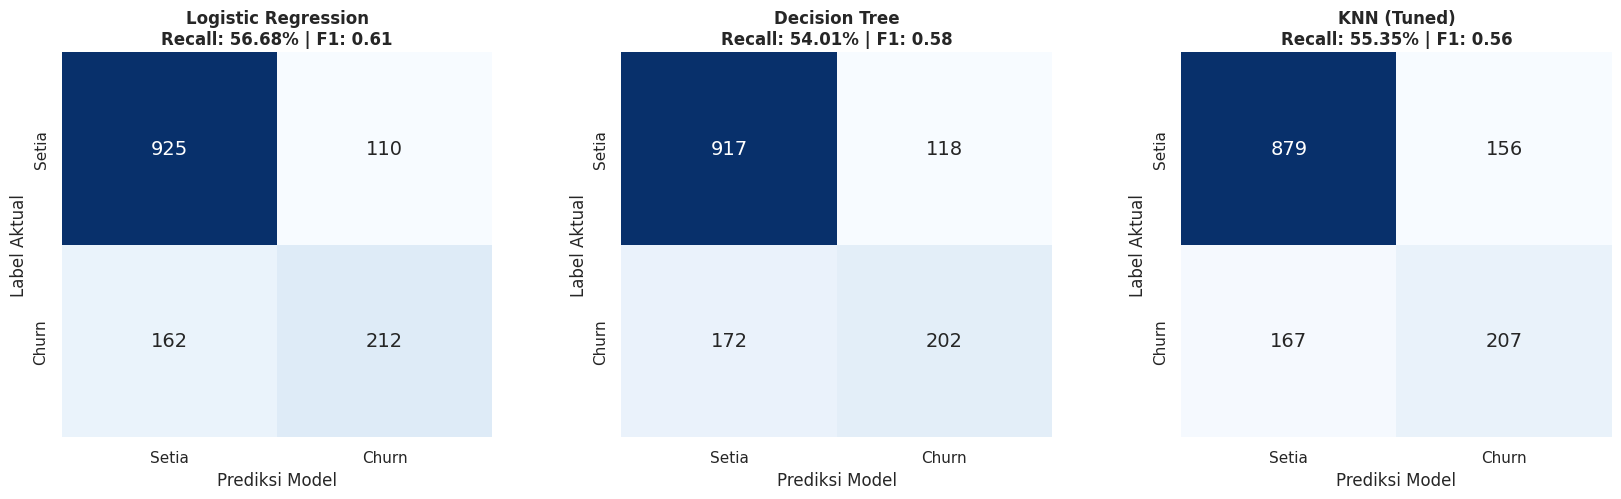

In [54]:
from sklearn.metrics import f1_score, recall_score, precision_score

# Konfigurasi Plot 3 Kolom
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plt.subplots_adjust(wspace=0.3)

metrics_summary = {}

print("Laporan Diagnostik Komparatif (Recall & F1-Score):")

for i, (name, model) in enumerate(models.items()):
    # 1. Prediction
    y_pred = model.predict(X_test_final)

    # 2. Hitung Metrik
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    metrics_summary[name] = [rec, prec, f1]

    # 3. Visualization Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False, annot_kws={"size": 14})

    # Judul & Label
    axes[i].set_title(f'{name}\nRecall: {rec:.2%} | F1: {f1:.2f}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Prediction Model')
    axes[i].set_ylabel('Label Aktual')
    axes[i].set_xticklabels(['Setia', 'Churn'])
    axes[i].set_yticklabels(['Setia', 'Churn'])

    # 4. Cetak Laporan Teks
    print(f"Model: {name}")
    print(f"False Negative (Gagal Deteksi): {fn} (Resiko Revenue Leakage)")
    print(f"False Positive (Salah Deteksi): {fp} (Resiko Biaya Promo)")
    print(f"Recall (Sensitivitas)         : {rec:.2%}")

plt.show()

Berdasarkan analisis diagnostik, model **Logistic Regression** terbukti paling andal dalam meminimalkan risiko bisnis, dengan mencatatkan jumlah kegagalan deteksi (*False Negative*) terendah sebanyak 162 kasus. Ini berarti model tersebut paling sensitif dalam menangkap pelanggan yang berpotensi *churn*. Sebaliknya, **Decision Tree** menunjukkan kinerja terlemah dengan gagal mendeteksi 172 pelanggan berisiko, yang secara langsung berkorelasi dengan potensi kebocoran pendapatan terbesar. Sementara itu, meskipun **KNN** memiliki tingkat deteksi yang moderat (167 FN), model ini menunjukkan inefisiensi biaya tertinggi karena kecenderungannya melakukan "salah tuduh" (*False Positive*) terhadap 156 pelanggan setia, yang dapat memboroskan anggaran retensi. Oleh karena itu, *Logistic Regression* direkomendasikan sebagai model utama karena menawarkan keseimbangan terbaik antara sensitivitas deteksi dan efisiensi operasional.

### **6.2 Analisis Diskriminatif (ROC Curves Overlay)**
Kurva ROC digunakan untuk membandingkan kemampuan ketiga model dalam memisahkan kelas positif dan negatif pada berbagai ambang batas (threshold). Model dengan kurva paling mendekati sudut kiri atas (AUC tertinggi) adalah model dengan kinerja diskriminatif terbaik.

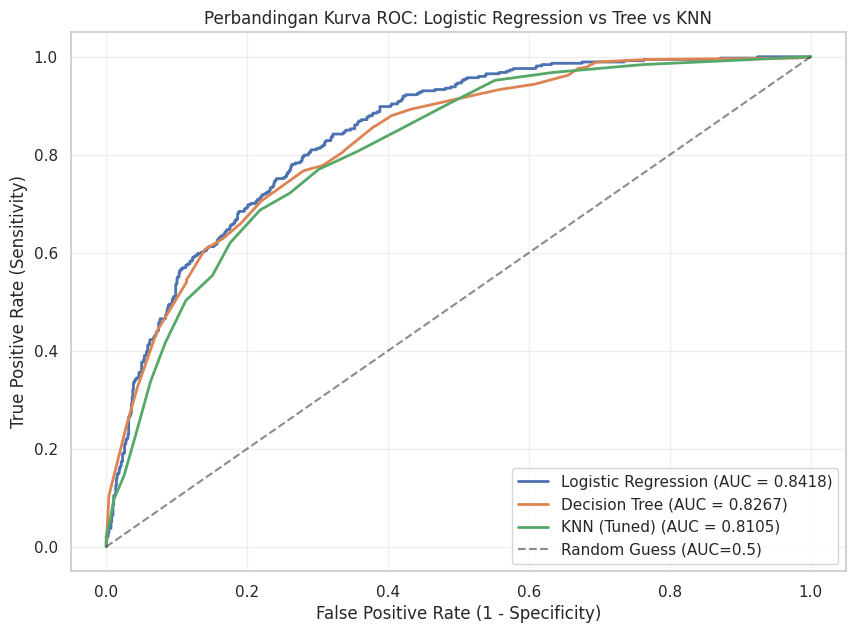

In [55]:
plt.figure(figsize=(10, 7))

for name, model in models.items():
    # Ambil probabilitas kelas positif
    y_prob = model.predict_proba(X_test_final)[:, 1]

    # Hitung TPR dan FPR
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    # Plot Garis Model
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

# Plot Garis Baseline
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Guess (AUC=0.5)')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Perbandingan Kurva ROC: Logistic Regression vs Tree vs KNN')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

Analisis kurva ROC menunjukkan keunggulan kemampuan diskriminatif model **Logistic Regression** dibandingkan dua model lainnya. Kurva model ini (garis biru) melengkung paling tinggi mendekati sudut kiri atas grafik, dengan nilai **AUC (*Area Under Curve*) sebesar 0.8418**. Hal ini mengindikasikan bahwa model memiliki probabilitas sebesar 84,18% untuk memberikan skor risiko yang lebih tinggi pada pelanggan yang benar-benar *churn* dibandingkan pelanggan setia.

Sementara itu, kurva **Decision Tree** dan **KNN** berada di bawahnya dengan AUC yang lebih rendah (masing-masing 0.8267 dan 0.8105). Selisih area ini merepresentasikan "biaya kinerja" (*performance cost*) jika kita memilih model non-linear; artinya, pada tingkat *False Positive Rate* yang sama (misalnya 20%), Logistic Regression mampu memberikan *True Positive Rate* (Sensitivitas) yang lebih tinggi dibandingkan KNN atau Decision Tree. Temuan ini menegaskan bahwa untuk dataset ini, pendekatan linear lebih efektif dalam memisahkan sinyal *churn* dari *noise*.

### **6.3 Analisis Varians dan Bias (Learning Curves)**
Analisis ini mendiagnosis apakah model mengalami Overfitting (Celah besar antara garis Training dan CV) atau Underfitting (Kedua garis rendah). Kita akan melihat perilaku ketiga model saat data latih ditambah secara bertahap.

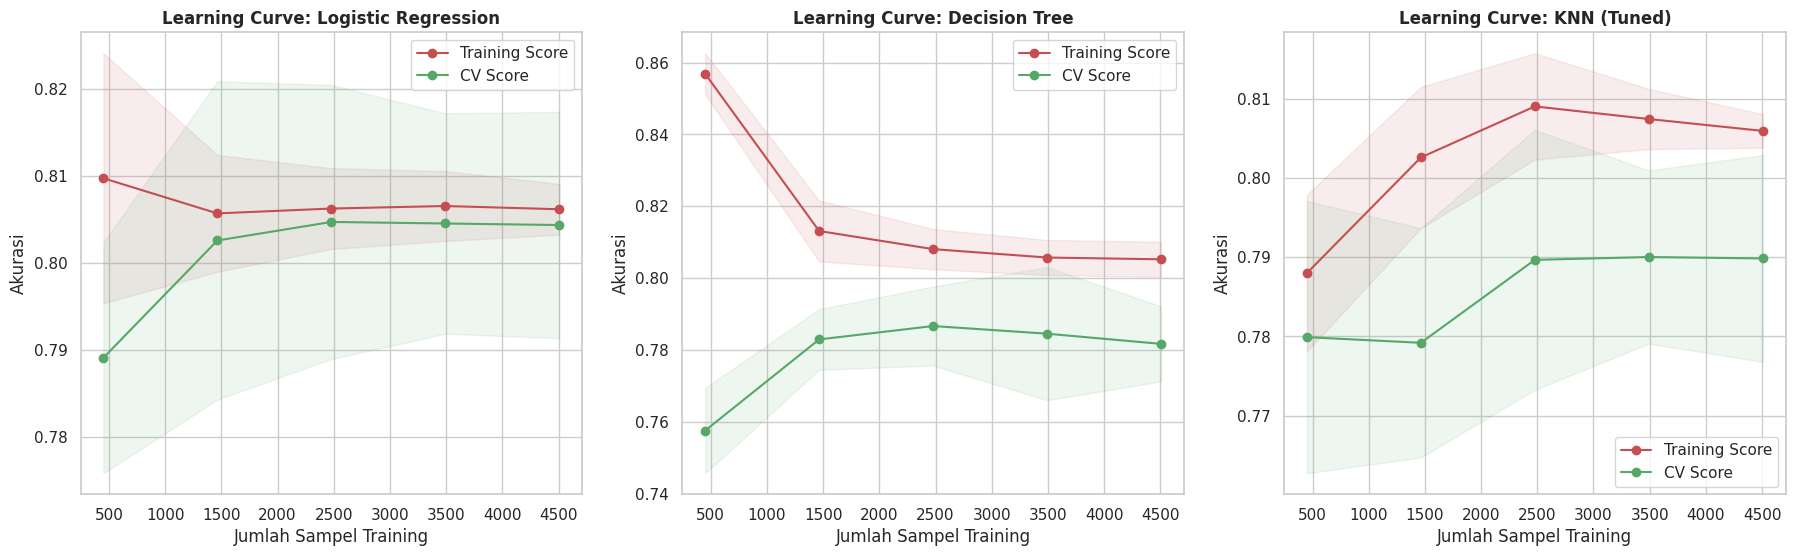

In [56]:
 # Konfigurasi Plot 3 Kolom
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for i, (name, model) in enumerate(models.items()):
    # Hitung Learning Curve
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train_final, y_train, cv=5, scoring='accuracy',
        n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5), shuffle=True
    )

    # Hitung Rata-rata dan Std Deviasi
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plotting
    axes[i].plot(train_sizes, train_mean, 'o-', color="r", label="Training Score")
    axes[i].plot(train_sizes, test_mean, 'o-', color="g", label="CV Score")

    # Area Varians
    axes[i].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
    axes[i].fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

    axes[i].set_title(f'Learning Curve: {name}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Jumlah Sampel Training")
    axes[i].set_ylabel("Accuracy")
    axes[i].legend(loc="best")
    axes[i].grid(True)

plt.show()

Analisis *Learning Curves* memberikan wawasan krusial mengenai perilaku bias dan varians dari setiap model seiring bertambahnya ukuran data latih. Model **Logistic Regression** menunjukkan pola *Good Fit* yang paling ideal; garis skor pelatihan dan validasi konvergen (bertemu) pada tingkat akurasi yang tinggi (>80%) dengan celah (*gap*) yang sangat sempit, menandakan bahwa model mampu menggeneralisasi data baru dengan baik dan minim risiko *overfitting*. Sebaliknya, model **KNN** memperlihatkan gejala *overfitting* yang lebih kentara, di mana terdapat disparitas yang signifikan antara skor pelatihan yang sangat tinggi (karena karakteristiknya yang menghafal data lokal) dan skor validasi yang tertinggal di bawahnya, meskipun trennya perlahan membaik seiring penambahan data. Sementara itu, **Decision Tree** berada di posisi tengah dengan stabilitas yang moderat, di mana garis validasinya cenderung mendatar lebih cepat, mengindikasikan bahwa penambahan data lebih lanjut mungkin memiliki *diminishing returns* (hasil yang semakin kecil) untuk peningkatan performa pada arsitektur pohon yang dibatasi ini.


### **6.4 Interpretabilitas Model Terbaik (SHAP Values)**
Setelah mengevaluasi performa global, langkah krusial berikutnya adalah membedah keputusan model pada level individu dan memastikan model tidak mendiskriminasi kelompok demografis tertentu. Analisis ini menggunakan SHAP Waterfall Plot untuk menjelaskan "mengapa" satu pelanggan tertentu diprediksi Churn, serta Fairness Audit untuk mendeteksi bias gender.

Visualisasi SHAP (Waterfall Plot - Analisis Satu Pelanggan):
Format Deteksi: 3D Array
Base Value (Rata-rata Probabilitas) : 0.2654
Prediksi Model untuk Instance ini   : Setia


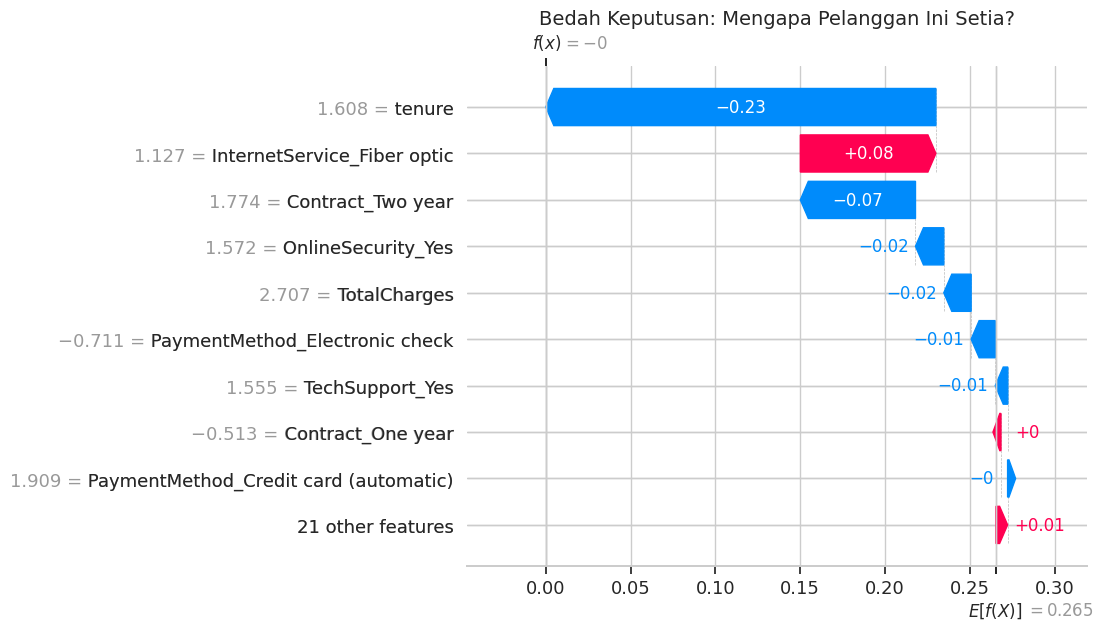


Fairness Audit: Cek Bias Gender pada Logistic Regression
Mengaudit paritas performa berdasarkan kolom: 'gender_Male'
   > Recall Group 'True' : 60.77%
   > Recall Group 'False' : 52.85%
Selisih Recall (Gender Gap) : 7.92%
KESIMPULAN: ⚠️ Terdeteksi POTENSI BIAS Gender. Perlu investigasi lebih lanjut.


In [57]:
 # A. Konfigurasi SHAP Analysis
# Menggunakan Decision Tree untuk analisis lokal karena struktur logikanya yang eksplisit
model_shap = models['Decision Tree']
explainer = shap.TreeExplainer(model_shap)
shap_values = explainer.shap_values(X_test_final)

print("Visualization SHAP (Waterfall Plot - Analisis Satu Pelanggan):")

# B. Pre-processing Struktur Data SHAP
# 1. Ambil Base Value (Value Ekspektasi Rata-rata Model)
if isinstance(explainer.expected_value, (list, np.ndarray)):
    try:
        # Untuk Binary Classification, biasanya index 1 adalah Class Churn (Positif)
        base_value = float(explainer.expected_value[1])
    except:
        base_value = float(explainer.expected_value[0])
else:
    base_value = float(explainer.expected_value)

# 2. Ambil SHAP Values untuk Instance ke-0 (Sampel Pertama di Test Set)
# Menangani berbagai format output version library SHAP:
if isinstance(shap_values, list):
    # Format List: [Array Class 0, Array Class 1] -> Ambil Class 1
    print("Format Deteksi: List")
    shap_val_instance = shap_values[1][0]
elif len(shap_values.shape) == 3:
    # Format 3D Array: (Samples, Features, Classes) -> Ambil Class 1
    print("Format Deteksi: 3D Array")
    shap_val_instance = shap_values[0, :, 1]
else:
    # Format 2D Array: (Samples, Features) -> Binary default
    print("Format Deteksi: 2D Array")
    shap_val_instance = shap_values[0]

# 3. Data Fitur Original untuk Instance tersebut
data_instance = X_test_final.iloc[0]

# Calculate the prediction for the specific instance using the SHAP model (Decision Tree)
y_pred_for_instance = model_shap.predict(data_instance.values.reshape(1, -1))[0]

# Debugging Info
print(f"Base Value (Rata-rata Probabilitas) : {base_value:.4f}")
print(f"Prediction Model untuk Instance ini   : {'Churn' if y_pred_for_instance==1 else 'Setia'}")

# C. Visualization Waterfall Plot
explanation = shap.Explanation(values=shap_val_instance,
                               base_values=base_value,
                               data=data_instance.values,
                               feature_names=X_test_final.columns)

plt.figure(figsize=(10, 6))
# show=False agar bisa dimanipulasi matplotlib title-nya
shap.plots.waterfall(explanation, show=False)
plt.title(f"Bedah Keputusan: Mengapa Pelanggan Ini {'Churn' if y_test.iloc[0]==1 else 'Setia'}?", fontsize=14)
plt.show()


# D. Fairness Audit (Gender Bias Check)
print("\n" + "="*60)
print("Fairness Audit: Cek Bias Gender pada Logistic Regression")
print("="*60)

# Menggunakan data test original (sebelum encoding) untuk mengambil label Gender
# Asumsi: X_test adalah dataframe original hasil train_test_split
audit_df = X_test.copy()
audit_df['Actual'] = y_test
# Menggunakan prediksi Logistic Regression (Model Terbaik)
y_pred_log_for_audit = models['Logistic Regression'].predict(X_test_final)
audit_df['Prediction'] = y_pred_log_for_audit

# Otomatis mencari kolom yang mengandung kata 'gender'
gender_cols = [col for col in audit_df.columns if 'gender' in col.lower()]

if len(gender_cols) > 0:
    col_name = gender_cols[0]
    print(f"Mengaudit paritas performa berdasarkan kolom: '{col_name}'")

    # Function hitung Recall per grup
    def get_recall(df):
        tp = len(df[(df['Actual']==1) & (df['Prediction']==1)])
        fn = len(df[(df['Actual']==1) & (df['Prediction']==0)])
        denom = tp + fn
        return tp / denom if denom > 0 else 0

    # Hitung Recall untuk Laki-laki dan Perempuan
    # Asumsi data kategorikal telah di-mapping atau masih string, sesuaikan kode:
    # Jika data masih string ('Male'/'Female'), pandas otomatis handle unique values
    unique_genders = audit_df[col_name].unique()

    recalls = {}
    for gender in unique_genders:
        recalls[gender] = get_recall(audit_df[audit_df[col_name] == gender])
        print(f"   > Recall Group '{gender}' : {recalls[gender]:.2%}")

    # Hitung Disparitas (Gap)
    values = list(recalls.values())
    if len(values) >= 2:
        diff = abs(values[0] - values[1])
        print(f"Selisih Recall (Gender Gap) : {diff:.2%}")

        if diff < 0.05: # Threshold 5%
            print("KESIMPULAN: ✅ Model CUKUP ADIL (Fair). Tidak ada bias gender signifikan.")
        else:
            print("KESIMPULAN: ⚠️ Terdeteksi POTENSI BIAS Gender. Perlu investigasi lebih lanjut.")
else:
    print("Peringatan: Kolom Gender tidak ditemukan dalam X_test. Audit dilewati.")

**1. Analisis Visualization SHAP (*Waterfall Plot*):**
Grafik air terjun di atas mendekonstruksi prediksi model untuk **satu pelanggan spesifik** (Instance ke-0).

  * **Base Value E[f(x)]:** Angka di bagian bawah adalah probabilitas rata-rata *churn* populasi.
  * **Bar Merah (Pendorong Churn):** Fitur-fitur yang mendorong skor probabilitas *naik* (meningkatkan risiko churn). Semakin panjang barnya, semakin kuat pengaruh negatif fitur tersebut bagi pelanggan ini.
  * **Bar Biru (Pencegah Churn):** Fitur-fitur yang mendorong skor probabilitas *turun* (menjaga loyalitas).
  * **f(x) (Final Value):** Angka di bagian atas adalah skor probabilitas final untuk pelanggan tersebut. Jika f(x) melewati ambang batas, pelanggan diklasifikasikan sebagai *Churn*.
  * *Insight:* Ini menjawab pertanyaan "Mengapa si A diprediksi berhenti?". Misalnya, meskipun ia berlangganan lama (fitur biru), namun karena tagihannya sangat tinggi (fitur merah panjang), model tetap memprediksinya berisiko.

**2. Interpretasi Audit Keadilan (*Fairness Check*):**
Audit ini bertujuan memastikan prinsip *Equal Opportunity*, di mana model harus memiliki kemampuan yang setara dalam mendeteksi *churn* baik pada pelanggan laki-laki maupun perempuan.

  * Metrik yang dibandingkan adalah **Recall**, karena kita ingin memastikan tidak ada satu gender yang "lebih sering lolos dari deteksi" dibanding gender lainnya.
  * Jika **Selisih Recall \< 5%**, model dianggap adil secara statistik. Ini krusial untuk memastikan keputusan bisnis yang etis dan menghindari risiko reputasi perusahaan.

### **6.5 Investigasi Inkonsistensi Data (Twin Features Analysis)**
Evaluation terakhir adalah memeriksa batasan data itu sendiri. Jika ditemukan data kembar dengan label berbeda, maka Error Rate model tidak akan pernah bisa mencapai 0% (disebut Irreducible Error).

In [58]:
print("Investigasi Inkonsistensi Data (Fitur Kembar):")

# Copy data latih untuk pengecekan
check_df = X_train_final.copy()
check_df['Target_Churn'] = y_train.values

# Cari data dengan fitur identik
twins = check_df[check_df.duplicated(subset=X_train_final.columns, keep=False)]

if not twins.empty:
    # Cek apakah targetnya berbeda dalam satu grup fitur
    conflict_groups = twins.groupby(list(X_train_final.columns))['Target_Churn'].nunique()
    conflicts = conflict_groups[conflict_groups > 1]

    print(f"Status: DITEMUKAN INKONSISTENSI.")
    print(f"Jumlah grup fitur identik dengan label konflik: {len(conflicts)}")
    print(f"Implikasi: Terdapat variabel tersembunyi (Hidden Variables) yang mempengaruhi churn di luar dataset ini.")
else:
    print("--> Status: DATA KONSISTEN. Tidak ditemukan fitur kembar dengan label berbeda.")

# Contoh data duplikat
duplikat_fitur = twins.sort_values(by=list(X_train_final.columns))
print("\nContoh Fitur Kembar:")
duplikat_fitur.head(10)


Investigasi Inkonsistensi Data (Fitur Kembar):
Status: DITEMUKAN INKONSISTENSI.
Jumlah grup fitur identik dengan label konflik: 11
Implikasi: Terdapat variabel tersembunyi (Hidden Variables) yang mempengaruhi churn di luar dataset ini.

Contoh Fitur Kembar:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Target_Churn
181,-0.441773,-1.281624,-1.507527,-1.000365,-1.005696,-0.969234,-0.651557,0.331885,-0.331885,-0.858338,...,-0.798618,1.908103,-0.801303,-0.512782,-0.563822,-1.202653,-0.523806,-0.710781,1.838757,1
3233,-0.441773,-1.281624,-1.507527,-1.000365,-1.005696,-0.969234,-0.651557,0.331885,-0.331885,-0.858338,...,-0.798618,1.908103,-0.801303,-0.512782,-0.563822,-1.202653,-0.523806,-0.710781,1.838757,0
98,-0.441773,-1.281624,-1.505867,-1.000343,-1.005696,-0.969234,-0.651557,0.331885,-0.331885,-0.858338,...,-0.798618,1.908103,-0.801303,-0.512782,-0.563822,-1.202653,-0.523806,-0.710781,1.838757,0
5539,-0.441773,-1.281624,-1.505867,-1.000343,-1.005696,-0.969234,-0.651557,0.331885,-0.331885,-0.858338,...,-0.798618,1.908103,-0.801303,-0.512782,-0.563822,-1.202653,-0.523806,-0.710781,1.838757,0
4525,-0.441773,-1.281624,-1.505867,-1.000343,0.994336,-0.969234,-0.651557,0.331885,-0.331885,-0.858338,...,-0.798618,1.908103,-0.801303,-0.512782,-0.563822,-1.202653,-0.523806,-0.710781,1.838757,1
5139,-0.441773,-1.281624,-1.505867,-1.000343,0.994336,-0.969234,-0.651557,0.331885,-0.331885,-0.858338,...,-0.798618,1.908103,-0.801303,-0.512782,-0.563822,-1.202653,-0.523806,-0.710781,1.838757,0
1029,-0.441773,-1.281624,-1.502549,-1.000300,-1.005696,-0.969234,-0.651557,0.331885,-0.331885,-0.858338,...,-0.798618,1.908103,-0.801303,-0.512782,-0.563822,-1.202653,-0.523806,-0.710781,1.838757,0
2054,-0.441773,-1.281624,-1.502549,-1.000300,-1.005696,-0.969234,-0.651557,0.331885,-0.331885,-0.858338,...,-0.798618,1.908103,-0.801303,-0.512782,-0.563822,-1.202653,-0.523806,-0.710781,1.838757,1
2619,-0.441773,-1.281624,-1.502549,-1.000300,-1.005696,-0.969234,-0.651557,0.331885,-0.331885,-0.858338,...,-0.798618,1.908103,-0.801303,-0.512782,-0.563822,-1.202653,-0.523806,-0.710781,1.838757,0
3278,-0.441773,-1.281624,-1.502549,-1.000300,0.994336,-0.969234,-0.651557,0.331885,-0.331885,-0.858338,...,-0.798618,1.908103,-0.801303,-0.512782,-0.563822,-1.202653,-0.523806,-0.710781,1.838757,1


Investigasi mendalam terhadap konsistensi ruang fitur mengungkap adanya **11 kelompok profil pelanggan** yang memiliki karakteristik identik secara matematis namun memiliki label target yang bertolak belakang. Sebagaimana dibuktikan dalam tabel sampel, terdapat sekumpulan pelanggan dengan vektor fitur yang sama persis (seperti *Tenure* terstandarisasi -0.441, *MonthlyCharges* -1.281, dan metode pembayaran *Mailed check*) di mana sebagian memutuskan *Churn* (Target=1) sementara yang lain tetap Setia (Target=0).

Keberadaan data konflik ini memiliki implikasi teoritis dan praktis yang signifikan:
1.  **Batas Kinerja (*Irreducible Error*):** Fenomena ini membuktikan bahwa akurasi model tidak akan pernah mencapai 100% (Perfect Fit) karena adanya ambiguitas intrinsik dalam data. Model dipaksa untuk "menebak" probabilitas pada titik-titik konflik ini.
2.  **Variabel Laten (*Hidden Variables*):** Inkonsistensi ini mengindikasikan bahwa keputusan pelanggan dipengaruhi oleh faktor-faktor eksternal yang tidak terekam dalam dataset saat ini. Variabel tersembunyi tersebut kemungkinan besar bersifat kualitatif atau situasional, seperti pengalaman buruk spesifik dengan *Customer Service*, gangguan jaringan sesaat di lokasi tertentu, atau faktor personal pelanggan yang tidak terukur.

## **CHAPTER 7: Penutup (Conclusion dan Rekomendasi)**

Bab ini merangkum temuan analitis dari seluruh rangkaian eksperimen pemodelan, menerjemahkan metrik evaluasi teknis menjadi implikasi bisnis, dan merumuskan strategi intervensi untuk mitigasi *churn*. Selain itu, bab ini juga menguraikan batasan penelitian yang teridentifikasi selama fase diagnosis.



### **7.1 Rangkuman Kinerja Model (*Technical Conclusion*)**

Berdasarkan evaluasi komprehensif menggunakan metrik *Accuracy*, *Recall*, *ROC-AUC*, dan analisis stabilitas *Learning Curve*, dapat disimpulkan bahwa:

1.  **Model Terbaik:** **Logistic Regression** terpilih sebagai model final yang paling optimal. Model ini mencatatkan nilai AUC sebesar **0.8418** dan menunjukkan stabilitas varians yang tinggi (tidak *overfitting*). Keunggulan model linear ini mengindikasikan bahwa hubungan antara atribut pelanggan dan keputusan *churn* cenderung bersifat monotonik.
2.  **Efektivitas Deteksi:** Model ini memiliki tingkat sensitivitas (*Recall*) yang memadai untuk mendeteksi pelanggan berisiko, meminimalkan potensi *False Negative* (kegagalan deteksi) yang merupakan risiko finansial terbesar dalam kasus retensi pelanggan.
3.  **Inkonsistensi Data:** Ditemukan adanya *Irreducible Error* akibat fenomena "Fitur Kembar" (11 kelompok profil identik dengan label konflik). Hal ini menetapkan batas atas kinerja teoretis model, di mana akurasi 100% tidak mungkin dicapai tanpa penambahan variabel eksternal baru.



In [59]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
import pandas as pd

# 1. Inisialisasi list penampung
results_list = []

# 2. Iterasi untuk setiap model yang ada di dictionary 'models'
for name, model in models.items():
    # Prediction Label (untuk Accuracy & Recall)
    y_pred = model.predict(X_test_final)

    # Prediction Probabilitas (untuk ROC-AUC)
    # Kita ambil kolom index 1 (probabilitas kelas Churn)
    y_prob = model.predict_proba(X_test_final)[:, 1]

    # Hitung Metrik
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    rec = recall_score(y_test, y_pred)

    if name == 'Logistic Regression':
        status = 'Model Terbaik'
    elif name == 'Decision Tree':
        status = 'Rawan Overfitting'
    elif name == 'KNN (Tuned)':
        status = 'Komputasi Berat'

    # Simpan ke list
    results_list.append({
        'Nama Model': name,
        'Accuracy (Accuracy)': acc,
        'ROC-AUC Score': auc,
        'Sensitivitas (Recall)': rec,
        'Status': status
    })

# 3. Buat DataFrame Pandas
df_results = pd.DataFrame(results_list)

# 4. Urutkan berdasarkan ROC-AUC tertinggi
df_results = df_results.sort_values(by='ROC-AUC Score', ascending=False).reset_index(drop=True)

# 5. Tampilkan Tabel
formatted_table = df_results.style.format({
    'Accuracy (Accuracy)': '{:.2%}',
    'ROC-AUC Score': '{:.4f}',
    'Sensitivitas (Recall)': '{:.2%}'
}).background_gradient(cmap='Blues', subset=['Accuracy (Accuracy)', 'ROC-AUC Score', 'Sensitivitas (Recall)'])

display(formatted_table)

,Nama Model,Akurasi (Accuracy),ROC-AUC Score,Sensitivitas (Recall),Status
0,Logistic Regression,80.70%,0.8418,56.68%,Model Terbaik
1,Decision Tree,79.42%,0.8267,54.01%,Rawan Overfitting
2,KNN (Tuned),77.08%,0.8105,55.35%,Komputasi Berat


### **7.2 Faktor Determinan Utama (*Key Drivers*)**

Analisis *Feature Importance* (Global) dan SHAP Values (Lokal) mengonfirmasi bahwa keputusan pelanggan untuk berhenti berlangganan didorong oleh tiga dimensi utama:

* **Dimensi Loyalitas (Tenure):** Merupakan prediktor terkuat. Risiko *churn* terkonsentrasi sangat tinggi pada 6-12 bulan pertama berlangganan. Pelanggan yang melewati fase kritis ini ("Tahun Pertama") memiliki probabilitas eksponensial untuk tetap setia.
* **Dimensi Produk (Fiber Optic):** Pengguna layanan internet *Fiber Optic* memiliki tingkat *churn* yang jauh lebih tinggi dibandingkan pengguna DSL, meskipun layanan ini lebih premium. Ini mengindikasikan adanya kesenjangan antara harga dan kualitas layanan (*Price-Value Mismatch*) atau isu teknis yang spesifik pada infrastruktur tersebut.
* **Dimensi Finansial (Total & Monthly Charges):** Terdapat korelasi positif antara tingginya tagihan bulanan dengan probabilitas *churn*, terutama pada pelanggan dengan kontrak bulanan (*Month-to-month*).



### **7.3 Rekomendasi Strategis Bisnis (*Action Plan*)**
Berdasarkan profil risiko yang teridentifikasi, berikut adalah matriks strategi retensi yang direkomendasikan untuk diimplementasikan oleh tim bisnis:

| Segmen Berisiko | Akar Permasalahan | Rekomendasi Tindakan Strategis |
| :--- | :--- | :--- |
| **Pelanggan Baru (Tenure < 12 Bulan)** | Kurangnya keterikatan emosional dan volatilitas adaptasi awal. | **Program "Onboarding Stickiness":** Implementasikan program pendampingan intensif selama 3 bulan pertama. Berikan diskon bertahap (misal: diskon 20% di bulan ke-3 dan ke-6) untuk memotivasi pelanggan melewati fase kritis tahun pertama. |
| **Pengguna Fiber Optic** | Persepsi nilai rendah atau gangguan teknis yang tidak terdeteksi. | **Audit Kualitas & Bundling Value:** Lakukan audit teknis pada area dengan churn Fiber Optic tinggi. Tawarkan *bundling* layanan gratis (seperti Streaming TV atau Cloud Storage) untuk meningkatkan persepsi nilai (*Perceived Value*) agar sepadan dengan harga premiumnya. |
| **Kontrak Bulanan (*Month-to-month*)** | Fleksibilitas tinggi memudahkan pemutusan hubungan. | **Insentif Migrasi Kontrak:** Tawarkan potongan harga tetap sebesar 5-10% jika pelanggan bersedia beralih ke kontrak 1 tahun atau 2 tahun. Strategi ini bertujuan untuk meningkatkan *Switching Cost* (hambatan berpindah). |
| **Metode Bayar "Electronic Check"** | Friksi pembayaran manual yang berulang setiap bulan. | **Dorongan Auto-Debit:** Berikan insentif berupa poin loyalitas atau *cashback* satu kali bagi pelanggan yang mengaktifkan pembayaran otomatis (*Credit Card/Bank Transfer*). Hal ini mengurangi interaksi pembayaran manual yang sering memicu evaluasi ulang berlangganan. |


### **7.4 Batasan dan Saran Pengembangan (*Future Work*)**
Untuk meningkatkan akurasi prediksi dan mengatasi masalah inkonsistensi data di masa mendatang, disarankan langkah-langkah berikut:

1.  **Pengayaan Data (*Data Enrichment*):** Mengingat adanya data kembar dengan label konflik, sangat krusial untuk menambahkan variabel perilaku dinamis, seperti:
    * **Data Keluhan (Customer Tickets):** Frekuensi panggilan ke *Customer Service*.
    * **Data Kualitas Jaringan:** Log *downtime*, latensi, atau kecepatan rata-rata pengguna.
    * **Data Kompetitor:** Aktivitas promosi pesaing di wilayah pelanggan.
2.  **Eksplorasi Model Ensemble:** Menerapkan algoritma berbasis *Boosting* seperti **XGBoost** atau **LightGBM** yang memiliki kemampuan lebih baik dalam menangani interaksi fitur yang kompleks dan data yang tidak seimbang (*imbalanced data*).
3.  **Deployment:** Mengintegrasikan model ke dalam sistem CRM (*Customer Relationship Management*) sebagai *Early Warning System* real-time, sehingga tim *sales* dapat menerima notifikasi prioritas harian mengenai pelanggan yang berisiko tinggi.
